In [1]:
import pandas as pd 
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/BookCrossingThemes_Updated.csv')

In [3]:
df.head()

,User-ID,Book-Title,Book-Author,ISBN,Year-Of-Publication,Publisher,Location,Age,category,description,num_words,num_chars,cleaned_description,Theme,Master-ISBN,Book-Rating,category_list,primary_category
0,114,A Kiss Remembered,Sandra Brown,446612618,2003,Warner Books,"ligonier, pennsylvania, usa",57,Fiction,"After leaving her disatrous marriage behind, S...",139,831,leaving disatrous marriage behind shelley brow...,Family Dynamics and Relationships,446612618,8,['Fiction'],Fiction
1,114,Angels & Demons,Dan Brown,671027360,2001,Pocket Star,"ligonier, pennsylvania, usa",57,Fiction,A novel about a symbologist who discovers the ...,17,107,novel symbologist discovers existence ancient ...,Epic Fantasy,743486226,10,['Fiction'],Fiction
2,114,The Alibi,Sandra Brown,446608653,2000,Warner Books,"ligonier, pennsylvania, usa",57,Fiction,In this suspenseful Southern thriller and #1 N...,115,699,suspenseful southern thriller 1 new york time ...,Crime Thrillers and Detective Drama,446608653,9,['Fiction'],Fiction
3,114,The Beach House,James Patterson,446612545,2003,Warner Books,"ligonier, pennsylvania, usa",57,Fiction,Jack Mullen is a driven student of the law. Hi...,94,533,jack mullen driven student law brother peter s...,Crime Thrillers and Detective Drama,446612545,9,['Fiction'],Fiction
4,114,The Short Forever,Stuart Woods,451208080,2003,Signet Book,"ligonier, pennsylvania, usa",57,Fiction,Stone Barrington gets caught up in a matter of...,92,555,stone barrington get caught matter internation...,Crime Thrillers and Detective Drama,451208080,8,['Fiction'],Fiction


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70479 entries, 0 to 70478
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   User-ID              70479 non-null  int64
 1   Book-Title           70479 non-null  str  
 2   Book-Author          70479 non-null  str  
 3   ISBN                 70479 non-null  str  
 4   Year-Of-Publication  70479 non-null  int64
 5   Publisher            70479 non-null  str  
 6   Location             70479 non-null  str  
 7   Age                  70479 non-null  int64
 8   category             67397 non-null  str  
 9   description          70479 non-null  str  
 10  num_words            70479 non-null  int64
 11  num_chars            70479 non-null  int64
 12  cleaned_description  70479 non-null  str  
 13  Theme                70479 non-null  str  
 14  Master-ISBN          70479 non-null  str  
 15  Book-Rating          70479 non-null  int64
 16  category_list        70479 non-nu

In [5]:
# Create age group buckets for analysis 
bins = [0, 12, 17, 59, 100]
labels = ['Children', 'Young Adult', 'Adult', 'Senior']
df['Age-Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [6]:
# Find the average rating per age group per category / theme

cat_stats = df.groupby(['Age-Group', 'primary_category'])['Book-Rating'].mean().reset_index()
theme_stats = df.groupby(['Age-Group', 'Theme'])['Book-Rating'].mean().reset_index()

In [7]:
# Highest rated category per age group
highest_rated_cat = df.groupby('Age-Group')['primary_category'].agg(lambda x: x.value_counts().index[0])

# Highest rated theme per age group
highest_rated_theme = df.groupby('Age-Group')['Theme'].agg(lambda x: x.value_counts().index[0])

print(highest_rated_cat)
print(highest_rated_theme)

Age-Group
Children       Juvenile Fiction
Young Adult             Fiction
Adult                   Fiction
Senior                  Fiction
Name: primary_category, dtype: str
Age-Group
Children                            Cozy Mysteries
Young Adult      Family Dynamics and Relationships
Adult            Family Dynamics and Relationships
Senior         Crime Thrillers and Detective Drama
Name: Theme, dtype: str


In [8]:
# create groups
children = df[df['Age-Group'] == 'Children']['Book-Rating']
young_adult = df[df['Age-Group'] == 'Young Adult']['Book-Rating']
adult = df[df['Age-Group'] == 'Adult']['Book-Rating']
senior = df[df['Age-Group'] == 'Senior']['Book-Rating']

f_stat, p_val = stats.f_oneway(children, young_adult, adult, senior)

print(p_val)

6.158433666967149e-08


In [11]:
# Create frequency table for categories
contingency_cat = pd.crosstab(df['Age-Group'], df['primary_category'])

# Create frequency table for themes
contingency_theme = pd.crosstab(df['Age-Group'], df['Theme'])

# Testing Category Preference
chi2, p_cat, dof, expected = chi2_contingency(contingency_cat)
print(f"Category Preference P-value: {p_cat}")

# Testing Theme Preference
chi2_t, p_theme, dof_t, expected_t = chi2_contingency(contingency_theme)
print(f"Theme Preference P-value: {p_theme}")



Theme        American Literature Classics  Apocalyptic Fiction  \
Age-Group                                                        
Children                                6                    0   
Young Adult                           117                    5   
Adult                                6070                  409   
Senior                                145                    6   

Theme        Arthurian Legend and Medieval Fantasy  Cozy Mysteries  \
Age-Group                                                            
Children                                         7               9   
Young Adult                                     53              43   
Adult                                         1589            1078   
Senior                                          22              47   

Theme        Crime Thrillers and Detective Drama  Culinary Arts  Epic Fantasy  \
Age-Group                                                                       
Children            

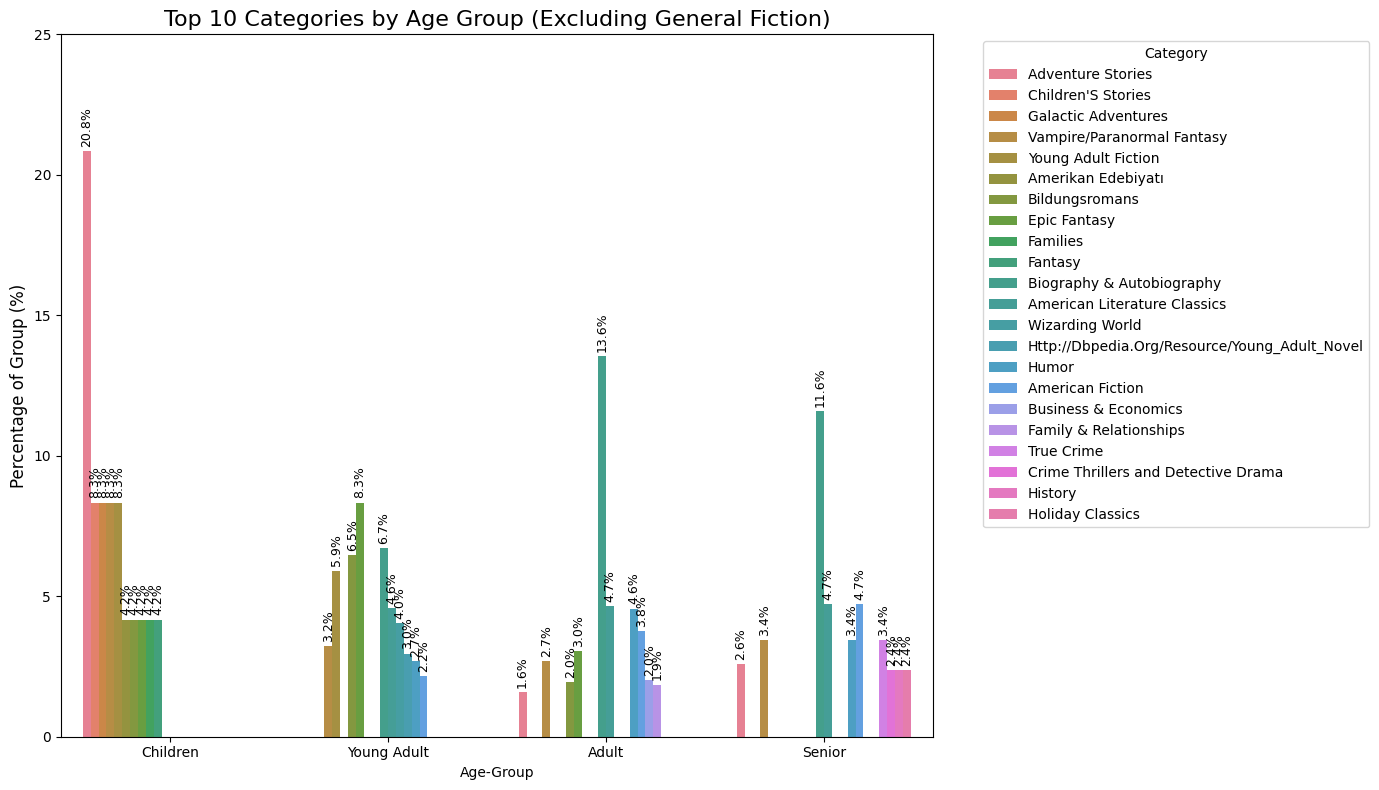

In [12]:
# OLD

# 1. Filter and prepare data
df_filtered = df[~df['primary_category'].isin(['Fiction', 'Juvenile Fiction'])]
plot_data = df_filtered.groupby(['Age-Group', 'primary_category']).size().reset_index(name='count')
plot_data['pct'] = plot_data.groupby('Age-Group')['count'].transform(lambda x: (x / x.sum()) * 100)
top_plot_data = plot_data.sort_values(['Age-Group', 'pct'], ascending=[True, False]).groupby('Age-Group').head(10)

# 2. Create the chart and ASSIGN IT TO 'ax'
plt.figure(figsize=(14, 8))
# Assigning the plot to 'ax' is the key fix here
ax = sns.barplot(data=top_plot_data, x='Age-Group', y='pct', hue='primary_category')

# 3. Now 'ax' exists, so we can add the labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, rotation=90, fontsize=9)

# 4. Final touches
plt.title('Top 10 Categories by Age Group (Excluding General Fiction)', fontsize=16)
plt.ylabel('Percentage of Group (%)', fontsize=12)
plt.ylim(0, top_plot_data['pct'].max() * 1.2) # Extra space for labels
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


/var/folders/76/79y9ksqx4kq5m3hsj5fpshhw0000gn/T/ipykernel_97352/1332928546.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


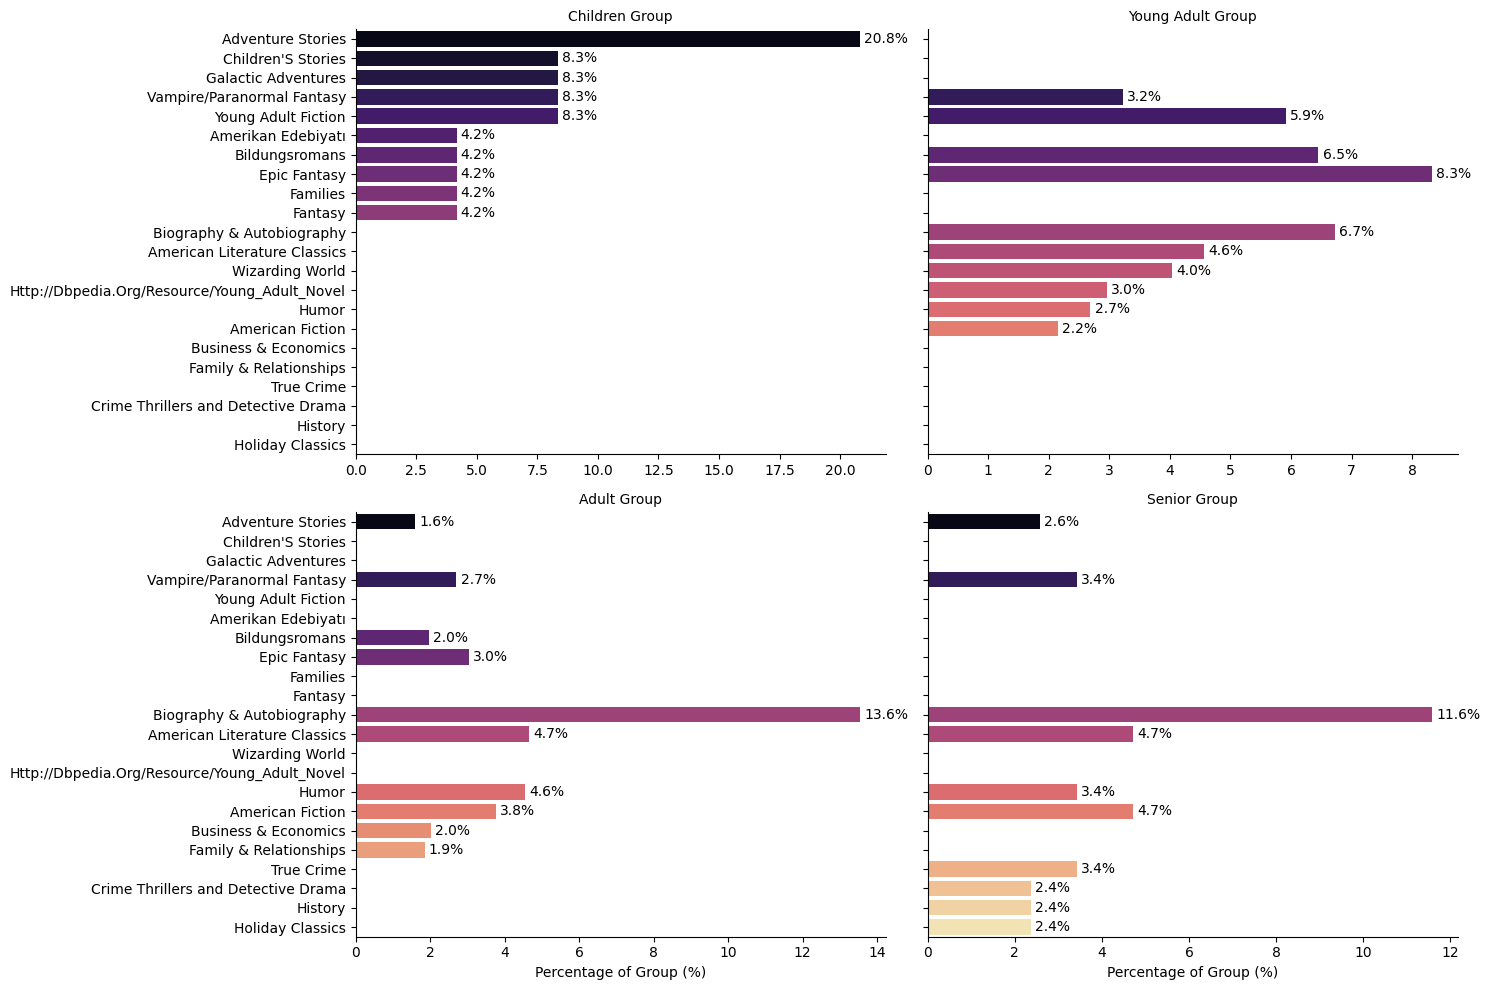

In [13]:
# 1. Filter and calculate percentages (as we did before)
df_filtered = df[~df['primary_category'].isin(['Fiction', 'Juvenile Fiction'])]
plot_data = df_filtered.groupby(['Age-Group', 'primary_category']).size().reset_index(name='count')
plot_data['pct'] = plot_data.groupby('Age-Group')['count'].transform(lambda x: (x / x.sum()) * 100)
top_data = plot_data.sort_values(['Age-Group', 'pct'], ascending=[True, False]).groupby('Age-Group').head(10)

# 2. Use FacetGrid to create 4 subplots (one for each Age Group)
# col_wrap=2 makes a 2x2 grid
g = sns.catplot(
    data=top_data, 
    y='primary_category',  # Category on Y makes labels easy to read
    x='pct', 
    col='Age-Group', 
    kind='bar', 
    col_wrap=2,
    sharex=False,           # Each group gets its own scale for better visibility
    height=5, 
    aspect=1.5,
    palette='magma'         # High contrast color palette
)

# 3. Add labels directly to the end of the bars for extra clarity
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3)

# 4. Clean up titles and layout
g.set_titles("{col_name} Group")
g.set_axis_labels("Percentage of Group (%)", "")
plt.tight_layout()
plt.show()

In [14]:
# Now look at location data 
# Extract country (last element after splitting by comma)
df['Country'] = df['Location'].str.split(',').str[-1].str.strip()

# Check for all unique countries
print(df['Country'].value_counts())


Country
usa                    54429
canada                  6645
                        2431
united kingdom          1454
australia                964
portugal                 669
malaysia                 656
germany                  477
spain                    431
netherlands              254
new zealand              184
france                   153
philippines              137
singapore                126
china                    122
austria                  103
italy                     94
romania                   93
brazil                    90
norway                    86
iran                      85
japan                     83
belgium                   72
finland                   62
switzerland               52
us                        44
sweden                    40
poland                    39
ireland                   32
united state              25
qatar                     24
trinidad and tobago       24
phillipines               23
venezuela                 21
domini

In [15]:
# Simple helper to extract parts safely
def get_location_part(loc, index):
    parts = str(loc).split(',')
    try:
        return parts[index].strip()
    except IndexError:
        return np.nan

df['City'] = df['Location'].apply(lambda x: get_location_part(x, 0))
df['State'] = df['Location'].apply(lambda x: get_location_part(x, -2))


In [16]:
# 1. Create a contingency table (cross-tabulation)
# Note: Filter for top states/categories first to avoid a massive, sparse table

# Define the top categories EXCLUDING "Fiction"
# Adjust the string "Fiction" if your Title Case version is different (e.g., "fiction")
all_top_cats = df['primary_category'].value_counts().index
non_fiction_cats = [c for c in all_top_cats if c != 'Fiction'][:20]

top_states = df['State'].value_counts().head(20).index
contingency_table = pd.crosstab(
    df[df['State'].isin(top_states)]['State'], 
    df['primary_category']
)

# 2. Run the Chi-Squared Test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2}")
print(f"P-value: {p}")

if p < 0.05:
    print("Result: Significant correlation! State likely influences category preference.")
else:
    print("Result: No significant correlation found.")


Chi-Square Statistic: 8147.63812641717
P-value: 1.523881549640041e-11
Result: Significant correlation! State likely influences category preference.


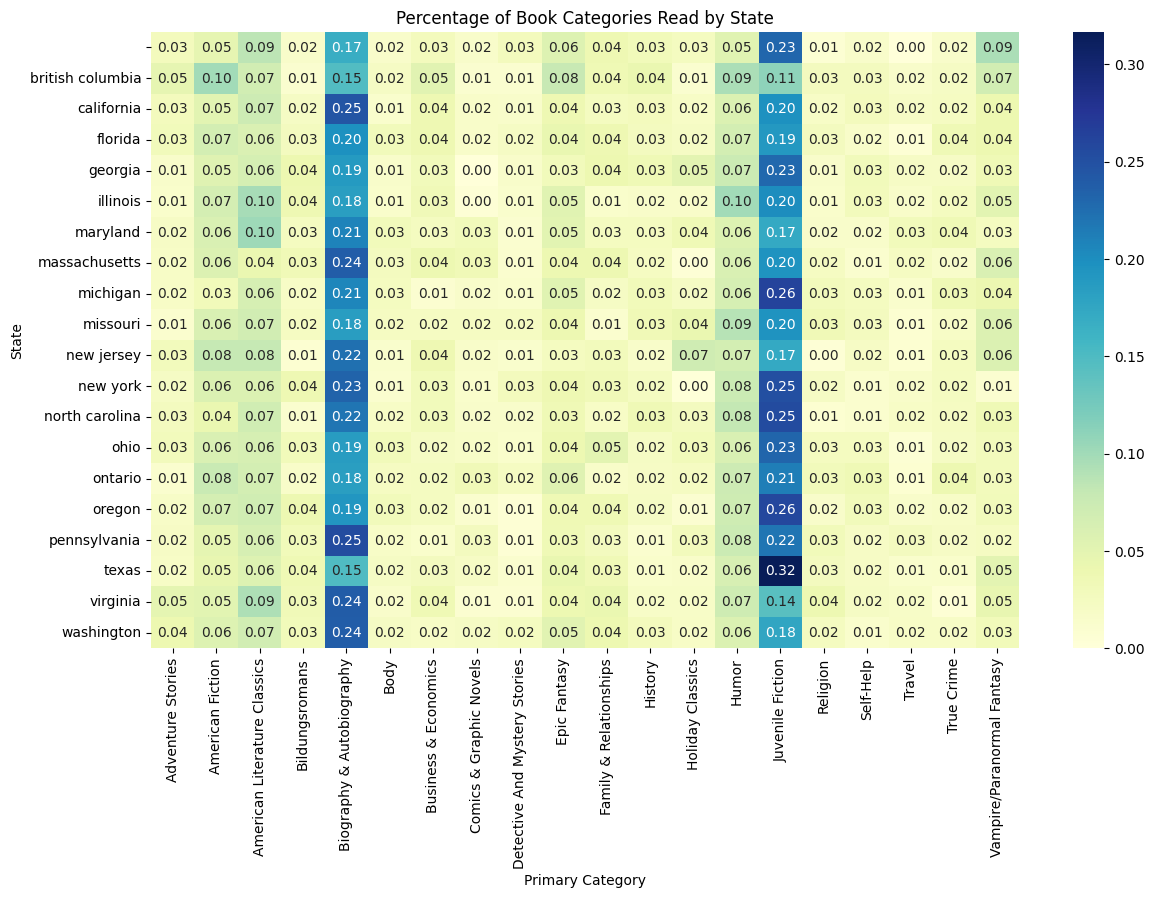

In [17]:
subset_df = df[
    (df['State'].isin(top_states)) & 
    (df['primary_category'].isin(non_fiction_cats))
]

# 2. Create the contingency table
contingency_table = pd.crosstab(subset_df['State'], subset_df['primary_category'])

# 3. Normalize by row (State) to show preference percentage
# This answers: "Of all readers in California, what % read Mystery?"
contingency_pct = contingency_table.div(contingency_table.sum(axis=1), axis=0)

# 4. Plot the heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(contingency_pct, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Percentage of Book Categories Read by State')
plt.xlabel('Primary Category')
plt.ylabel('State')
plt.show()


In [18]:
# Run the test on the filtered subset
chi2_sub, p_sub, dof_sub, expected_sub = chi2_contingency(contingency_table)

print(f"Sub-Category Chi-Square Statistic: {chi2_sub:.2f}")
print(f"Sub-Category P-value: {p_sub:.4f}")

if p_sub < 0.05:
    print("Confirmed: Even without Fiction, states have unique niche preferences!")


Sub-Category Chi-Square Statistic: 557.97
Sub-Category P-value: 0.0000
Confirmed: Even without Fiction, states have unique niche preferences!


Country Test P-value: 0.0000


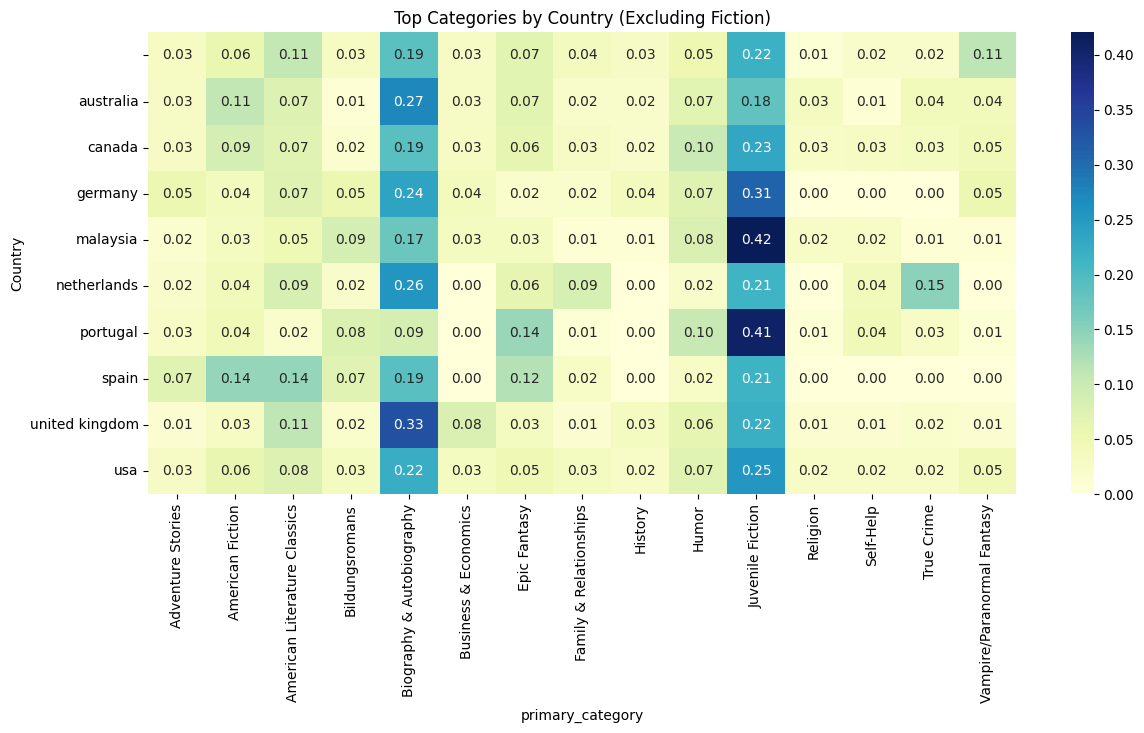

In [19]:
# 1. Identify Top 10 Countries (excluding 'Fiction')
top_countries = df['Country'].value_counts().head(10).index
non_fiction_cats = [c for c in df['primary_category'].value_counts().index if c != 'Fiction'][:15]

# 2. Filter and Create Contingency Table
country_df = df[
    (df['Country'].isin(top_countries)) & 
    (df['primary_category'].isin(non_fiction_cats))
]
ct_country = pd.crosstab(country_df['Country'], country_df['primary_category'])

# 3. Chi-Squared Test
chi2, p, _, _ = chi2_contingency(ct_country)
print(f"Country Test P-value: {p:.4f}")

# 4. Heatmap (Normalized)
plt.figure(figsize=(14, 6))
sns.heatmap(ct_country.div(ct_country.sum(axis=1), axis=0), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Top Categories by Country (Excluding Fiction)')
plt.show()


City Test P-value: 0.0000


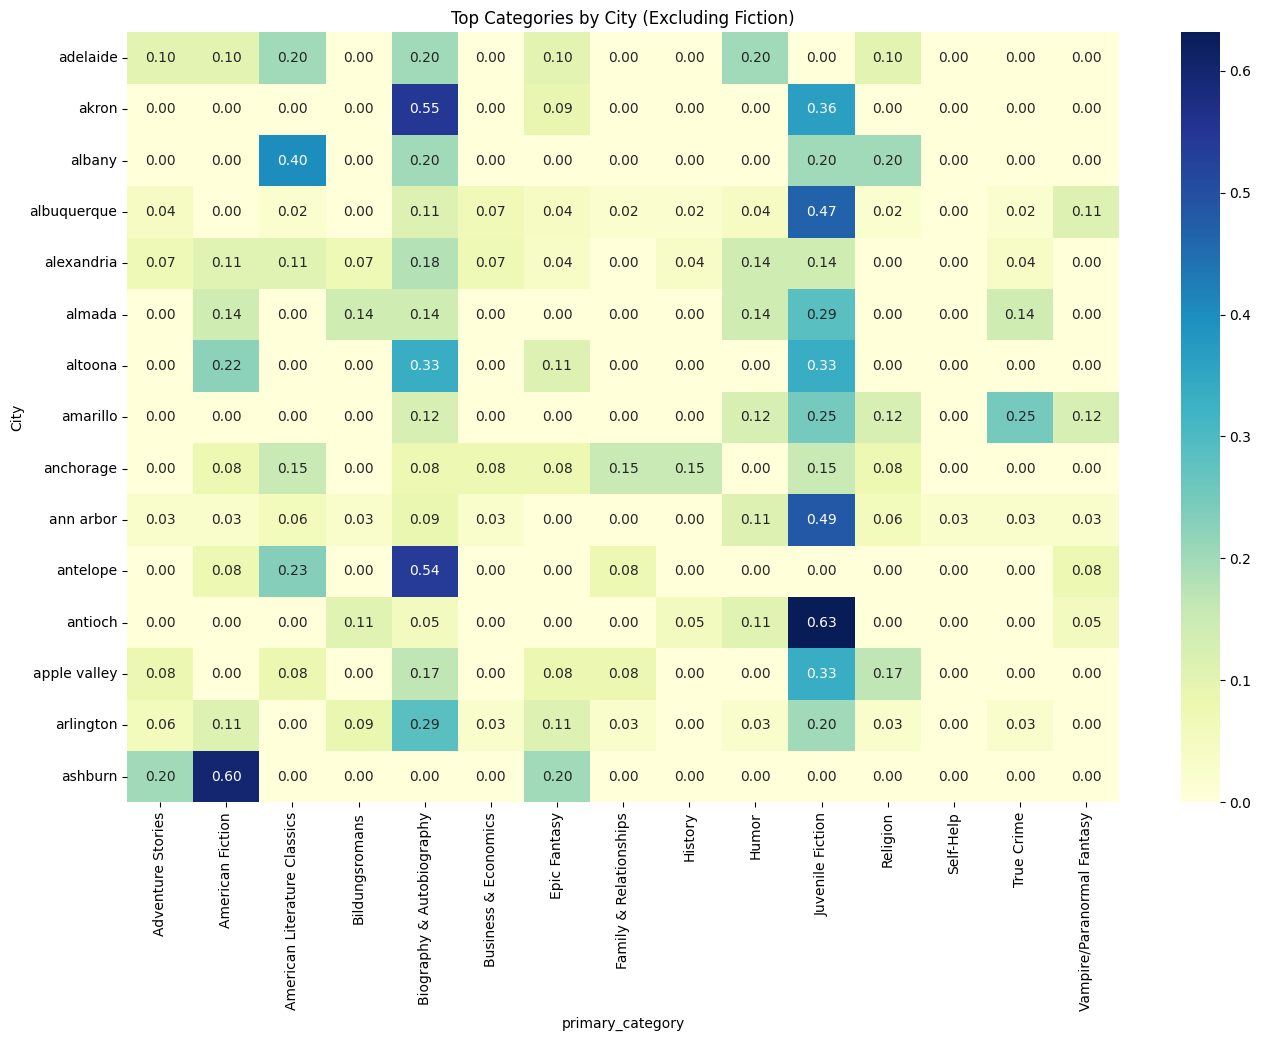

In [20]:
# 1. Filter for Cities with at least 50 ratings
city_counts = df['City'].value_counts()
top_cities = city_counts[city_counts >= 50].index

# 2. Filter and Create Contingency Table
city_df = df[
    (df['City'].isin(top_cities)) & 
    (df['primary_category'].isin(non_fiction_cats))
]
ct_city = pd.crosstab(city_df['City'], city_df['primary_category'])

# 3. Chi-Squared Test
chi2_city, p_city, _, _ = chi2_contingency(ct_city)
print(f"City Test P-value: {p_city:.4f}")

# 4. Heatmap (Top 15 Cities only for readability)
plt.figure(figsize=(16, 10))
sns.heatmap(ct_city.div(ct_city.sum(axis=1), axis=0).head(15), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Top Categories by City (Excluding Fiction)')
plt.show()


In [21]:
# Group by category and see how many unique themes each one has
category_purity = df.groupby('primary_category')['Theme'].nunique().sort_values(ascending=False)

print("Categories that span the MOST themes (Low Correlation):")
print(category_purity.head(10))

print("\nCategories that are 100% tied to ONE theme (High Correlation):")
print(category_purity[category_purity == 1].head(10))


Categories that span the MOST themes (Low Correlation):
primary_category
Fiction                      25
Biography & Autobiography    23
Juvenile Fiction             22
History                      14
Social Science               11
American Fiction             11
Comics & Graphic Novels      10
Family & Relationships       10
Humor                         9
Drama                         9
Name: Theme, dtype: int64

Categories that are 100% tied to ONE theme (High Correlation):
primary_category
Http://Dbpedia.Org/Resource/Memoir            1
Friendship                                    1
Frasier (Television Program).                 1
Holocaust                                     1
Http://Dbpedia.Org/Resource/Bildungsroman     1
Ghost Stories                                 1
Georgia                                       1
Http://Dbpedia.Org/Resource/Horror_Fiction    1
Holiday Classics                              1
Girls                                         1
Name: Theme, dtype: 